In [1]:
import h5py
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

plt.rcParams['figure.figsize'] = [16, 10]

In [2]:
def find_pfx(file, pfx):
    for k in file:
        if k.startswith(pfx):
            return k

In [3]:
def read_domain(file):
    mrc_domain = file[find_pfx(file, 'mrc_domain')]
    domain = { 'm': mrc_domain.attrs['m'] }
    return domain

In [4]:
def read_mfields(file):
    fields = {}
    for k in file:
        if k.startswith('mrc_fld'):
            mrc_fld = file[k]
            for kk in mrc_fld:
                group = file[k + '/' + kk]
                dsets = [group[p]['3d'] for p in group]
                fields[kk] = dsets
    return fields

In [5]:
def read_mcrds(file):
    mrc_crds = file[find_pfx(file, 'mrc_crds')]

    mcrds = {}
    for d, crd in enumerate(['x', 'y', 'z']):
        mcrds_path = 'mrc_m1_{}'.format(mrc_crds.attrs['mcrd{}'.format(d)][0])
        group = file[mcrds_path]
        paths = [p + "/1d" for p in group]
        dsets = [group[path] for path in paths]
        mcrds[crd] = dsets
        
    return mcrds

In [6]:
def read_pfd(path, step, nodes=1):
    files = [h5py.File(path + '/pfd.t{:06d}_n{:06d}.h5'.format(step, node)) for node in range(nodes)]

    fields = defaultdict(list)
    crds = defaultdict(list)
    for file in files:
        mfields = read_mfields(file)
        for f in mfields:
            fields[f] += mfields[f]
        mcrds = read_mcrds(file)
        for f in mcrds:
            crds[f] += mcrds[f]
            
    return fields, crds

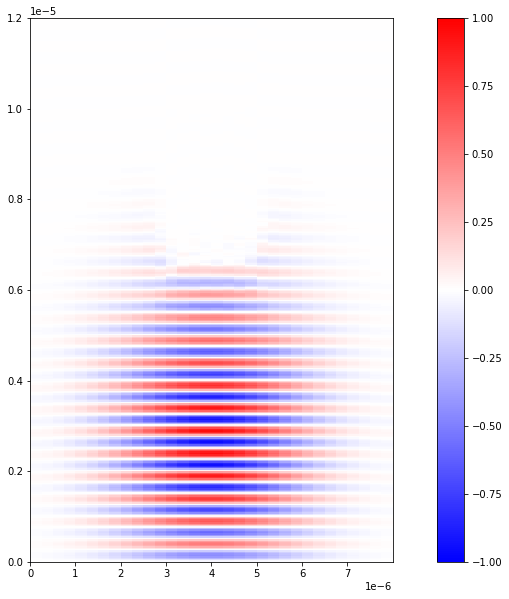

In [7]:
fields, crds = read_pfd('BNNT2', step=120, nodes=4)
for dset, xx, yy, zz in zip(fields['ex'], crds['x'], crds['y'], crds['z']):
    plt.pcolormesh(xx, zz, dset[:,16,:], cmap='bwr')
    plt.clim(-1., 1.)

plt.gca().set_aspect(1)
plt.colorbar();

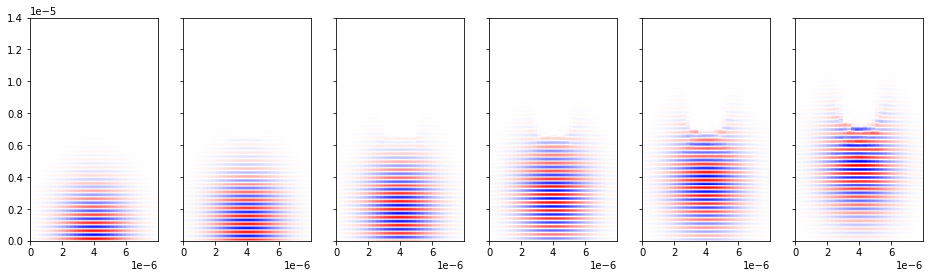

In [8]:
steps = range(0, 210, 40)
fig, ax = plt.subplots(1, len(steps), sharey=True)
for i, step in enumerate(steps):
    fields, crds = read_pfd('BNNT2', step=step, nodes=4)
    for dset, xx, yy, zz in zip(fields['ex'], crds['x'], crds['y'], crds['z']):
        ax[i].pcolormesh(xx, zz, dset[:,16,:], cmap='bwr', vmin=-1., vmax=1.)
        ax[i].set_aspect(1)
    #plt.colorbar()